---
title: Agent-based models and Monte Carlo simulations
short_title: "Day 3: Monte Carlo methods"
---

# Agent-based models and Monte Carlo simulations

## Random number generators in numpy

Monte Carlo simulation is good way to investigate stochastic processes. In order to run Monte Carlo simulations we need to generate random samples from probability distributions, and the required utilities can be found in the `numpy.random` module

Note that the `numpy.random` module provides both a legacy interface (functions of the forms `np.random.<name>()`) and a Generator-based interface (first use  `np.random.default_rng()` to create a Generator instance, and then use it to produce random samples)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Legacy interface

In [2]:
# generate 10000 pairs of random numbers between 0 and 1 using the legacy interface
N_pairs = 10000
rng_pairs = np.random.random(size=(N_pairs, 2))

In [3]:
# find the number of pairs that fall within the unit circle, and hence estimate pi
within_sum = np.sum((rng_pairs[:, 0]**2 + rng_pairs[:, 1]**2) < 1)
4 * within_sum / N_pairs # estimate of pi

np.float64(3.1332)

### Generator interface

In [4]:
# create a random generator instance
rng = np.random.default_rng()

In [5]:
# generate 10000 pairs of random numbers between 0 and 1
N_pairs = 10000
rng_pairs = rng.random(size=(N_pairs, 2))

In [6]:
# find the number of pairs that fall within the unit circle, and hence estimate pi
within_sum = np.sum((rng_pairs[:, 0]**2 + rng_pairs[:, 1]**2) < 1)
4 * within_sum / N_pairs # estimate of pi

np.float64(3.1444)

The `numpy.random` modules can be used to generate samples from many different probability distributions. For more information, read the [documentation of the legacy interface](https://numpy.org/doc/2.4/reference/random/legacy.html) or the [documentation of the Generator interface](https://numpy.org/doc/2.4/reference/random/generator.html).

## Example: Monte Carlo simulation of trait dynamics

**Model overview**

1. Phenotype (conceptualized as size) identified with genotype: $Z_i = G_i$
2. Survival: $p_i = \exp\{-(Z_i - \theta)^2 / (2 \, {\sigma_S}^2)\}$; draw **Bernoulli** survival
3. Reproduction: survivors each produce offspring $\sim \text{Poisson}(\lambda_0)$ (size-independent); the survivor itself dies after reproducing.
4. Inheritance: offspring genotype $G_{\text{child}} = G_{\text{parent}} + M_i$ with $M_i \sim \mathcal{N}(0, \sigma_M)$

We will simulate **N generations**

### Setup

In [7]:
rng = np.random.default_rng()

In [8]:
N = 20 # number of generations/iterations
P0 = 10 # initial population size

In [9]:
theta = 100 # optimal size
sigma_S = 10.0 # selection sensitivity
lambda_0 = 1.2 # mean number of offsprings
sigma_M = 2.0 # mutation SD

In [10]:
# initialize the first generation

G0_mean = 90.0
G0_sd = 20.0

G0 = rng.normal(G0_mean, G0_sd, size=P0)  # breeding values (genotypes)

In [11]:
G0

array([125.24989451,  88.6717961 ,  99.84716149,  88.1720912 ,
        87.92782374,  92.67597397,  93.87907386,  86.69025615,
        43.17066554,  51.06107765])

### Try one step of the iteration

In [12]:
p_survive = np.exp( -(G0 - theta)**2 / (2 * sigma_S**2) )

In [13]:
p_draw = rng.random(P0)

In [14]:
p_draw < p_survive

array([False,  True,  True, False, False,  True, False, False, False,
       False])

In [15]:
G1_parents = G0[p_draw < p_survive]

In [16]:
G1_parents

array([88.6717961 , 99.84716149, 92.67597397])

In [17]:
G1_counts = rng.poisson(lambda_0, size=len(G1_parents))
G1_total = G1_counts.sum()

In [18]:
G1_counts

array([0, 3, 1])

In [19]:
G1_inh = np.zeros(G1_total)
idx_next = 0
for idx, count in enumerate(G1_counts):
    G1_inh[idx_next:(idx_next+count)] = G1_parents[idx]
    idx_next += count

In [20]:
G1_inh

array([99.84716149, 99.84716149, 99.84716149, 92.67597397])

In [21]:
G1_mut = rng.normal(0, sigma_M, size=G1_total)

In [22]:
G1_mut

array([-3.16663186,  1.39027552, -2.50903899, -0.30191873])

In [23]:
G1 = G1_inh + G1_mut

In [24]:
G1

array([ 96.68052964, 101.23743701,  97.3381225 ,  92.37405524])

### Set up iteration

In [25]:
rng = np.random.default_rng()

N = 20 # number of generations/iterations
P0 = 100 # initial population size

theta = 100 # optimal size
sigma_S = 10.0 # selection sensitivity
lambda_0 = 1.2 # mean number of offsprings
sigma_M = 2.0 # mutation SD

G0_mean = 90.0
G0_sd = 20.0

G0 = rng.normal(G0_mean, G0_sd, size=P0)  # breeding values (genotypes)

In [26]:
G_current = G0
G_all = [ G0 ]

for i in range(N):

    p_survive = np.exp( -( G_current - theta)**2 / (2 * sigma_S**2) )
    p_draw = rng.random(len(G_current))

    G_next_parents = G_current[p_draw < p_survive]

    G_next_counts = rng.poisson(lambda_0, size=len(G_next_parents))
    G_next_total = G_next_counts.sum()

    if (G_next_total==0):
        print(f"population went extinct after {i} iterations")
        break

    G_next_inh = np.zeros(G_next_total)
    idx_next = 0
    for idx, count in enumerate(G_next_counts):
        G_next_inh[idx_next:(idx_next+count)] = G_next_parents[idx]
        idx_next += count

    G_next_mut = rng.normal(0, sigma_M, size=G_next_total)
    G_current = G_next_inh + G_next_mut
    G_all.append(G_current)
    

### Compute summary statistics and visualize

In [27]:
# Find the number of individuals per generation
pop_size = np.array([len(_x) for _x in G_all])

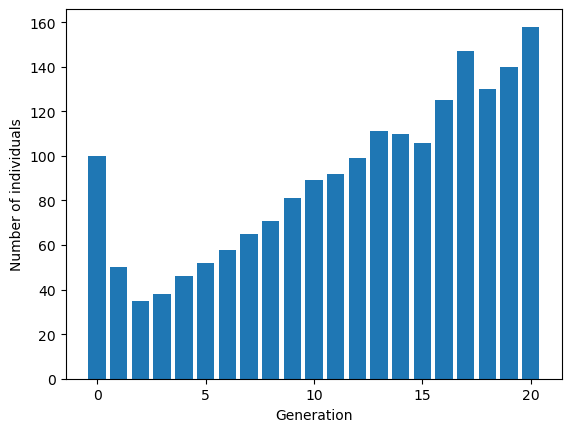

In [28]:
fig = plt.figure()
ax = fig.add_subplot()

ax.bar(np.arange(len(pop_size)), pop_size)
ax.set_xlabel("Generation")
ax.set_ylabel("Number of individuals")

plt.show(fig)

In [29]:
size_mean = np.array([np.mean(_x) for _x in G_all])
size_sd = np.array([np.std(_x) for _x in G_all])

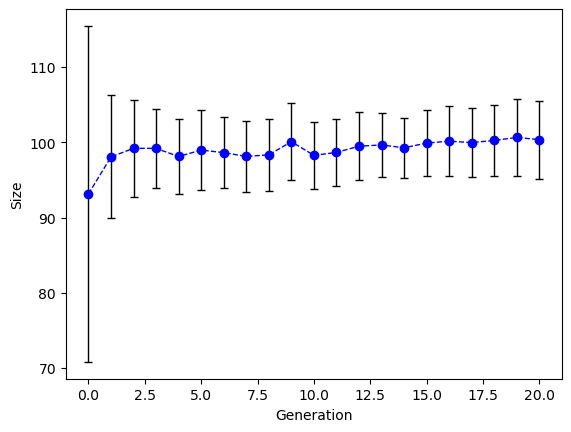

In [30]:
fig = plt.figure()
ax = fig.add_subplot()

ax.errorbar(
    np.arange(len(pop_size)), size_mean, yerr=size_sd,
    color="blue", marker="o", lw=1, ls="--", 
    ecolor="black", capsize=3.0
)

ax.set_xlabel("Generation")
ax.set_ylabel("Size")

plt.show(fig)

## Exercise: an agent-based foraging model

Consider the following foraging model:

1. An individual starts with an energy level of $E_0$ = 0.5.
2. The energy level of the individual cannot exceeds $E_\text{max}$ = 1.0 at the start of any time step $k$.
3. The individual is starved to death if its energy level $E_k$ is 0 or less at the start of any time step $k$.
4. At each time step, the individual spends energy $E_\text{cost}$ to obtain food, where $E_\text{cost}$ is exponentially distributed with mean $E_\text{mean}$
5. The energy gained from food consumption $E_\text{gain}$ is uniformly distributed between $E_\text{low}$ and $E_\textrm{high}$

For concreteness, take $E_\text{mean}$ = 0.2, $E_\text{low}$ = 0.15 and $E_\text{high}$ = 0.25, and take the number of time steps to be $K$ = 50. Estimate the probability that an individual would survive till the end of the $K$ steps.